# Projet de prédiction de temps de livraison des commades.


## Preparer l'environenment : 
- ### <span style="color:blue">Import necessary librairies </span>



<br><br>


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from haversine import haversine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.datasets import make_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from geopy.distance import geodesic
from scipy.stats import f_oneway

import pickle

<br>

- ### <span style="color:green">Utils
<br>

In [2]:
def draw(df):
    plt.figure(figsize=(16, 20))  # augmenter la hauteur pour 7 subplots
    
    cols = ['temps_livraison_min',
            'distance_km',               
            'zone_temporelle',        
            'Type_of_vehicle',        
            'multiple_deliveries',    
            'Weatherconditions',      
            'Delivery_person_Age']
    
    for i, col in enumerate(cols):
        plt.subplot(4, 2, i + 1)  # 4 lignes × 2 colonnes = 8 places (7 utilisées)
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f'Distribution de {col}')
    
    plt.tight_layout()
    plt.show()

def draw_variable(df, variable):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[variable], kde=True, bins=30, color='blue')
    plt.title(f"Distribution de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Fréquence")
    plt.show()

def draw_boxplot_variable(df, variable):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[variable])
    plt.title(f"Valeurs aberrantes pour {variable}")
    plt.show()

def draw_categ(df, variable):
    plt.figure(figsize=(10, 6))
    df[variable].value_counts().plot(kind='bar')
    plt.title(f"Répartition des catégories pour {variable}")
    plt.show()

def draw_categ_impact(df, variable, cible):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[variable], y=df[cible])
    plt.title(f"Impact des catégories de {variable} sur Time_taken(min)")
    plt.xticks(rotation=45)
    plt.show()

def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] >= lower) & (df[column] <= upper)]    

def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'    

<br>

- ### <span style="color:blue">Extraire la DATA SET
<br>

In [3]:
df = pd.read_csv('train.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


<br>

- ### <span style="color:blue">Trouver les NaN
<br>


In [4]:

df.replace({"NaN": np.nan}, regex=True, inplace = True)

print(df.isnull().sum())
print("Nombe des duplicats : ", df.duplicated().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64
Nombe des duplicats :  0


<br>

- ### <span style="color:blue">Enlever les colonnes unutiles</span> <br>

In [5]:
df_set = df.copy();
colonnes_unutiles = ["ID", "Delivery_person_ID", "Festival"]

df_set.drop(columns=colonnes_unutiles, inplace=True)

df_set.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,City,Time_taken(min)
0,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,Urban,(min) 24
1,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,Metropolitian,(min) 33
2,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,Urban,(min) 26
3,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,Metropolitian,(min) 21
4,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,Metropolitian,(min) 30


<br>

## Personnaliser la Data Set    
- ### <span style="color:blue">Time_taken (cible)</span> <br>

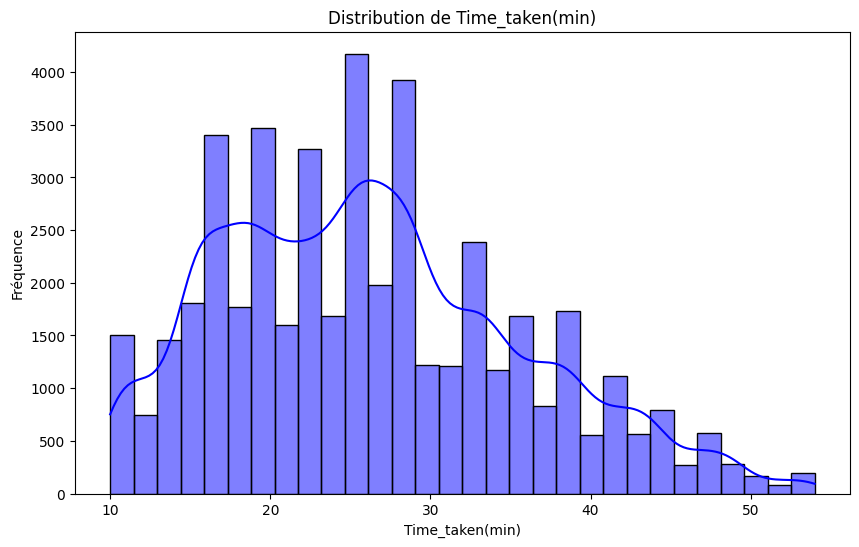

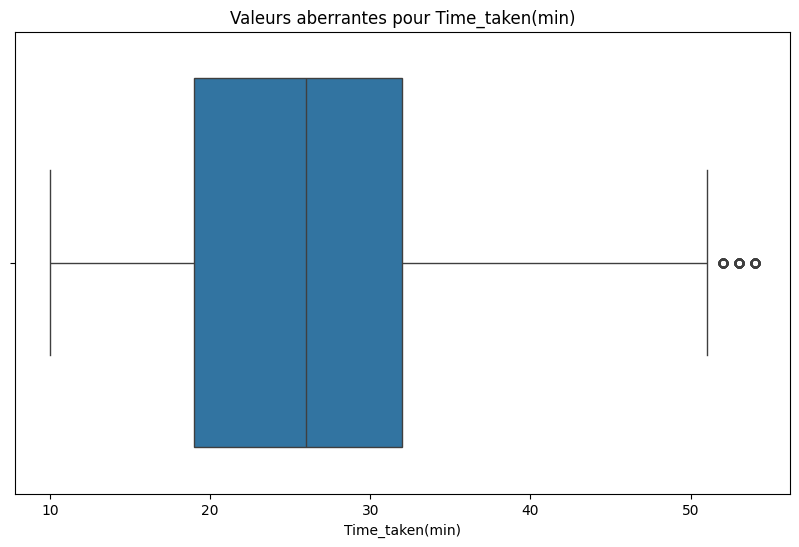

In [6]:
# Enlever (min) des valeurs 

df_set['Time_taken(min)'] = df_set['Time_taken(min)'].str.replace(r'\(min\)', '', regex=True).astype(float)

draw_variable(df_set, 'Time_taken(min)')
draw_boxplot_variable(df_set, 'Time_taken(min)')

- On consate quelque valeurs adherente au dela de 50 min, on doit les imputer

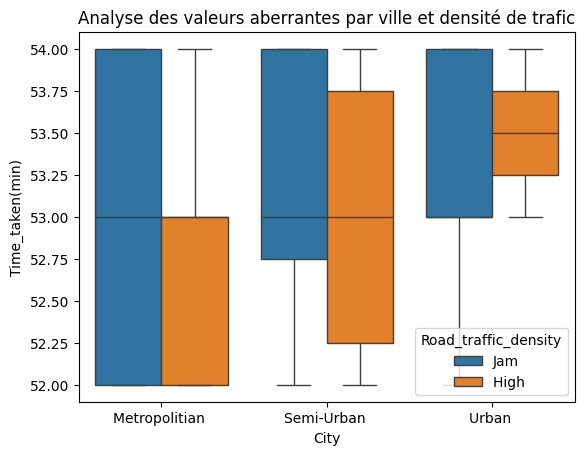

In [7]:
Q1 = df_set['Time_taken(min)'].quantile(0.25)
Q3 = df_set['Time_taken(min)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Valeurs aberrantes
outliers = df_set[(df_set['Time_taken(min)'] < lower_bound) | (df_set['Time_taken(min)'] > upper_bound)]

df_set = df_set[(df_set['Time_taken(min)'] >= lower_bound) & (df_set['Time_taken(min)'] <= upper_bound)]


sns.boxplot(x='City', y='Time_taken(min)', data=outliers, hue='Road_traffic_density')
plt.title("Analyse des valeurs aberrantes par ville et densité de trafic")
plt.show()


<br>

## Personnaliser la Data Set    
- ### <span style="color:blue">Variables categorielles</span> <br>

- Weather conditions

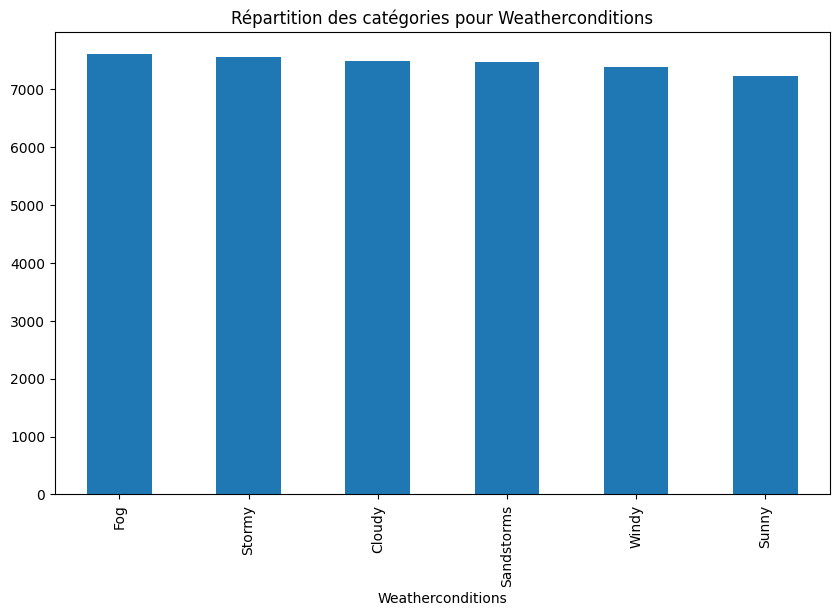

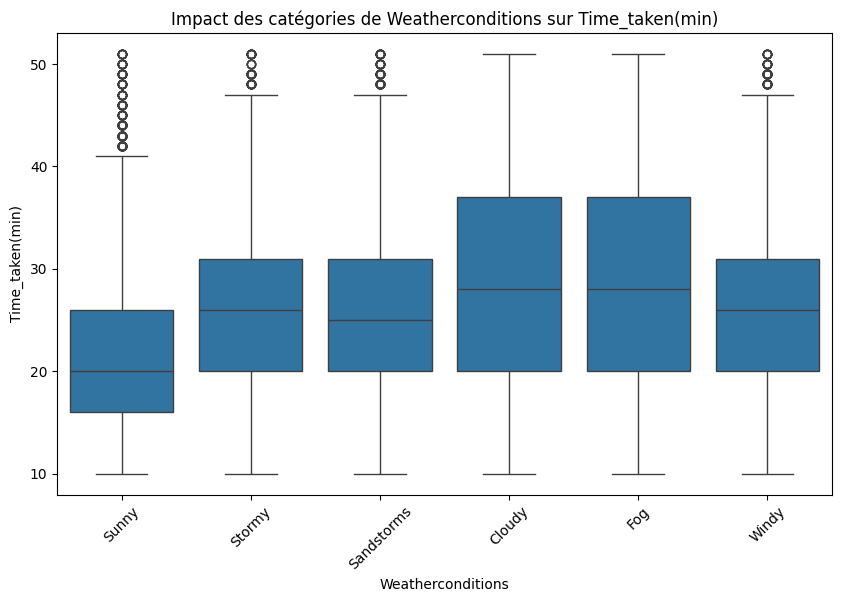

In [8]:
# Reformuler WeatherConditions
df_set['Weatherconditions'] = df_set['Weatherconditions'].str.replace(r'conditions\s*', '', regex=True)


draw_categ(df_set, 'Weatherconditions')
draw_categ_impact(df_set, 'Weatherconditions', 'Time_taken(min)')


In [9]:
# Analyser les valeurs abérentes dans la colonne weatherconditions

# Analyse des valeurs uniques et de leur fréquence
print(df_set['Weatherconditions'].value_counts())

# Proportion de valeurs manquantes
print(f"Proportion de valeurs manquantes : {df_set['Weatherconditions'].isnull().mean() * 100:.2f}%")


Weatherconditions
Fog           7597
Stormy        7549
Cloudy        7492
Sandstorms    7463
Windy         7378
Sunny         7233
Name: count, dtype: int64
Proportion de valeurs manquantes : 1.35%


In [10]:
# Imputation de weatherconditions
'''
distribution = df_set['Weatherconditions'].value_counts(normalize=True)

missing_indices = df_set['Weatherconditions'][df_set['Weatherconditions'].isnull()].index
df_set.loc[missing_indices, 'Weatherconditions'] = np.random.choice(
    distribution.index, size=len(missing_indices), p=distribution.values
)
'''
df_set.update(df_set['Weatherconditions'].fillna(df_set['Weatherconditions'].mode()[0]))
df_set.isnull().sum()


Delivery_person_Age            1837
Delivery_person_Ratings        1891
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1716
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            596
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             990
City                           1198
Time_taken(min)                   0
dtype: int64

- Road_traffic_density

Road_traffic_density
Low        15477
Jam        13902
Medium     10947
High        4401
Name: count, dtype: int64
Proportion de valeurs manquantes : 1.32%


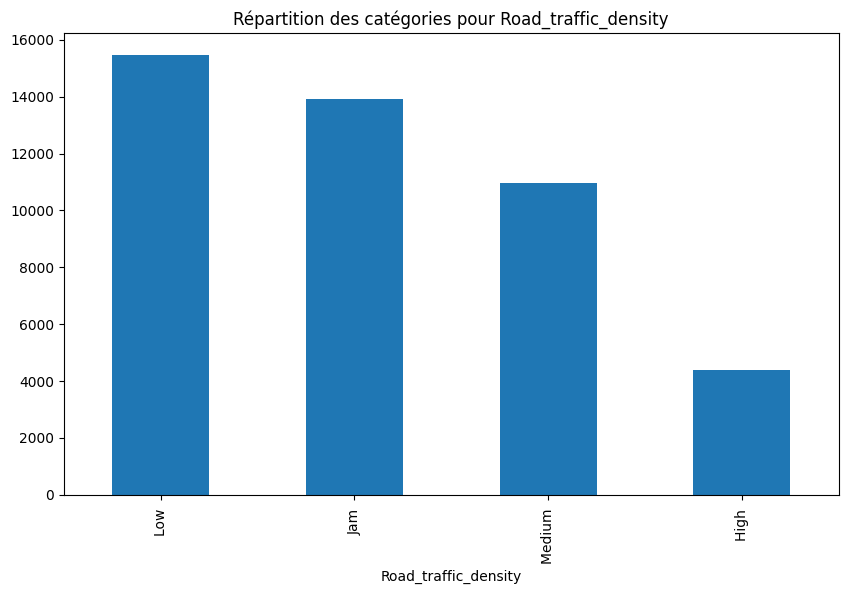

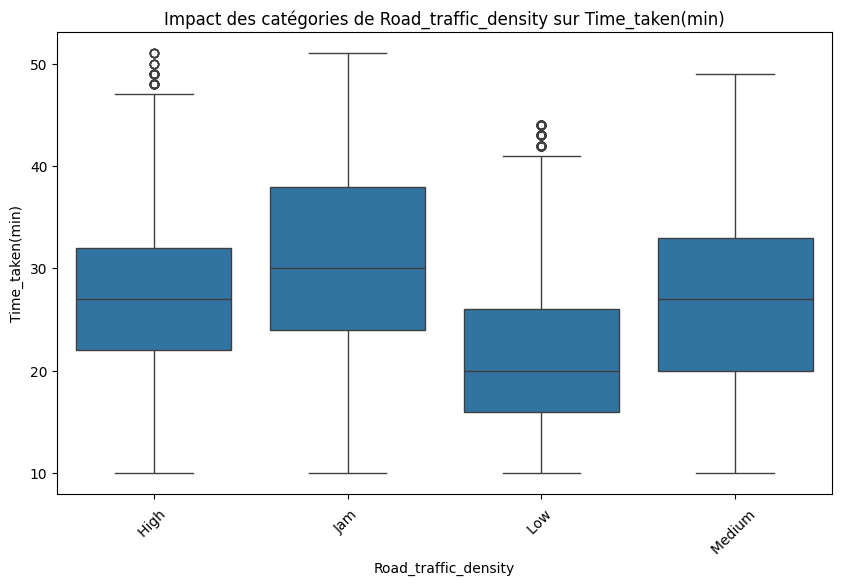

In [11]:
# Analyse des valeurs uniques et de leur fréquence
print(df_set['Road_traffic_density'].value_counts())

# Proportion de valeurs manquantes
print(f"Proportion de valeurs manquantes : {df_set['Road_traffic_density'].isnull().mean() * 100:.2f}%")

draw_categ(df_set, 'Road_traffic_density')
draw_categ_impact(df_set, 'Road_traffic_density', 'Time_taken(min)')

In [12]:
# Calcul des limites pour chaque catégorie de Road_traffic_density
categories = df_set['Road_traffic_density'].unique()
outliers = {}

for category in categories:
    subset = df_set[df_set['Road_traffic_density'] == category]['Time_taken(min)']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[category] = subset[(subset < lower_bound) | (subset > upper_bound)]

# supression des valeurs abérentes
for category, values in outliers.items():
    # Remplacer les valeurs de Road_traffic_density par NaN pour les lignes correspondantes
    df_set.loc[
        (df_set['Road_traffic_density'] == category) & (df_set['Time_taken(min)'].isin(values)),
        'Road_traffic_density'
    ] = np.nan

print(df_set['Road_traffic_density'].isnull().sum())

829


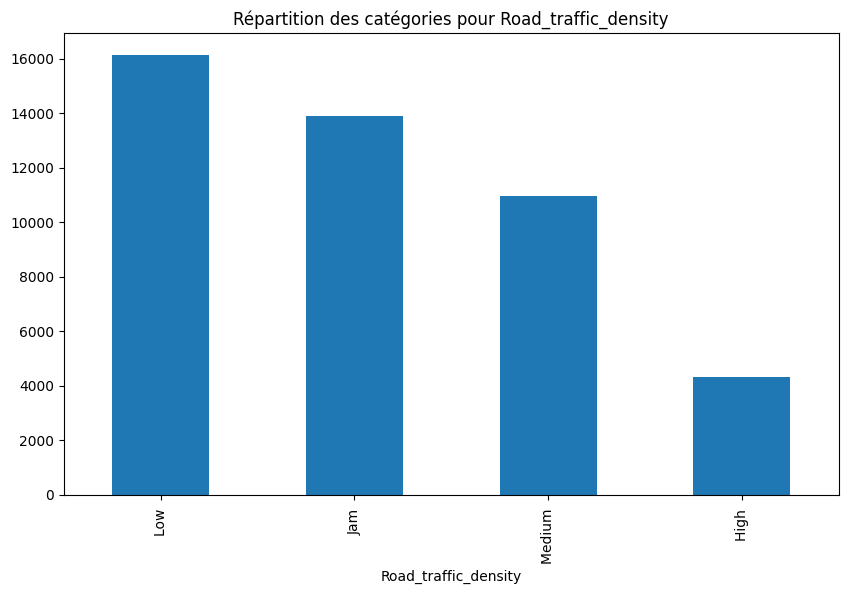

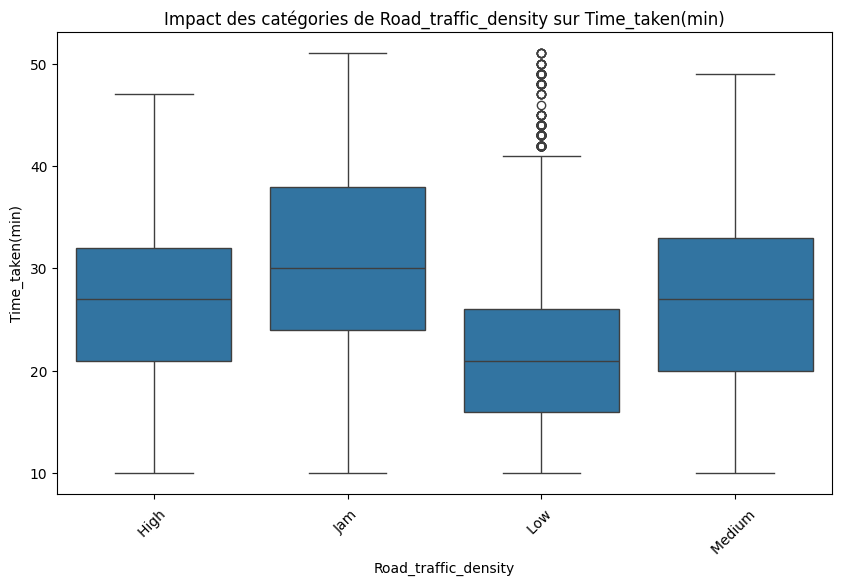

In [13]:
# Imputer les valeurs de Road traffic density
df_set.update(df_set['Road_traffic_density'].fillna(df_set['Road_traffic_density'].mode()[0]))
draw_categ(df_set, 'Road_traffic_density')
draw_categ_impact(df_set, 'Road_traffic_density', 'Time_taken(min)')

- Type_of_order

Type_of_order
Snack      11458
Meal       11393
Drinks     11262
Buffet     11210
Name: count, dtype: int64


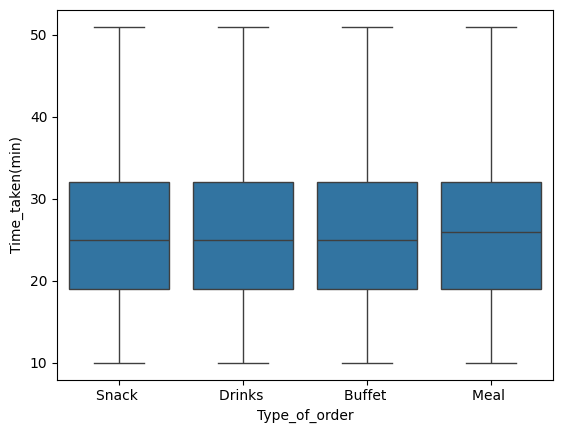

In [14]:
print(df_set['Type_of_order'].value_counts())

sns.boxplot(x='Type_of_order', y='Time_taken(min)', data=df_set)

# Eliminer la variable Type_of_order car elle n'est pas decisives
df_set = df_set.drop(columns=['Type_of_order'])


- Type_of_vehicle

Type_of_vehicle
motorcycle           26168
scooter              15274
electric_scooter      3813
bicycle                 68
Name: count, dtype: int64
Type_of_vehicle
motorcycle          26168
scooter             15274
electric_scooter     3813
Name: count, dtype: int64


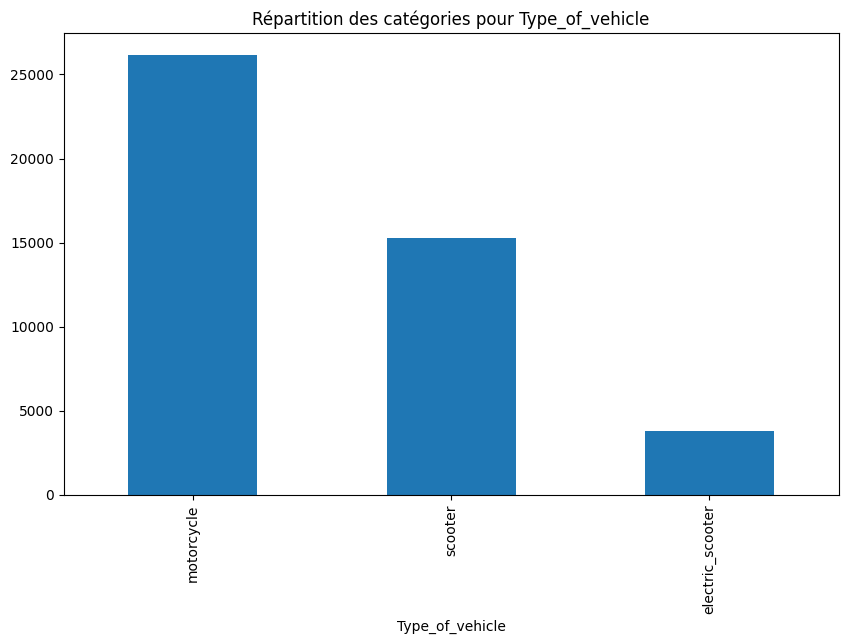

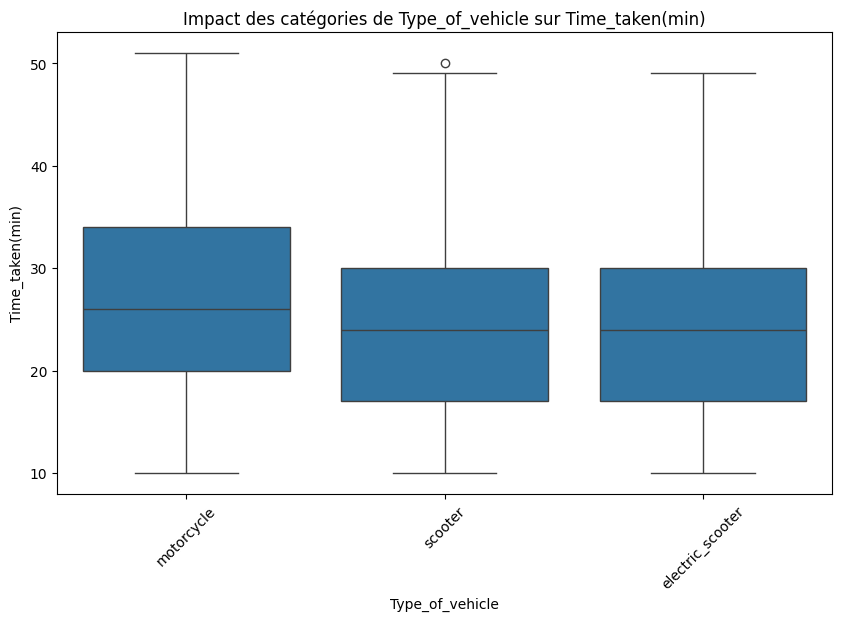

In [15]:
print(df_set['Type_of_vehicle'].value_counts())
df_set['Type_of_vehicle'] = df_set['Type_of_vehicle'].str.strip()
df_set = df_set[df_set['Type_of_vehicle'] != 'bicycle']

print(df_set['Type_of_vehicle'].value_counts())
draw_categ(df_set, 'Type_of_vehicle')
draw_categ_impact(df_set, "Type_of_vehicle", "Time_taken(min)")


- City

{'Urban': 275      50.0
285      47.0
413      49.0
447      48.0
479      50.0
         ... 
43922    49.0
44170    48.0
44738    49.0
45481    47.0
45576    48.0
Name: Time_taken(min), Length: 111, dtype: float64, 'Metropolitian': Series([], Name: Time_taken(min), dtype: float64), 'Semi-Urban': Series([], Name: Time_taken(min), dtype: float64), nan: Series([], Name: Time_taken(min), dtype: float64)}


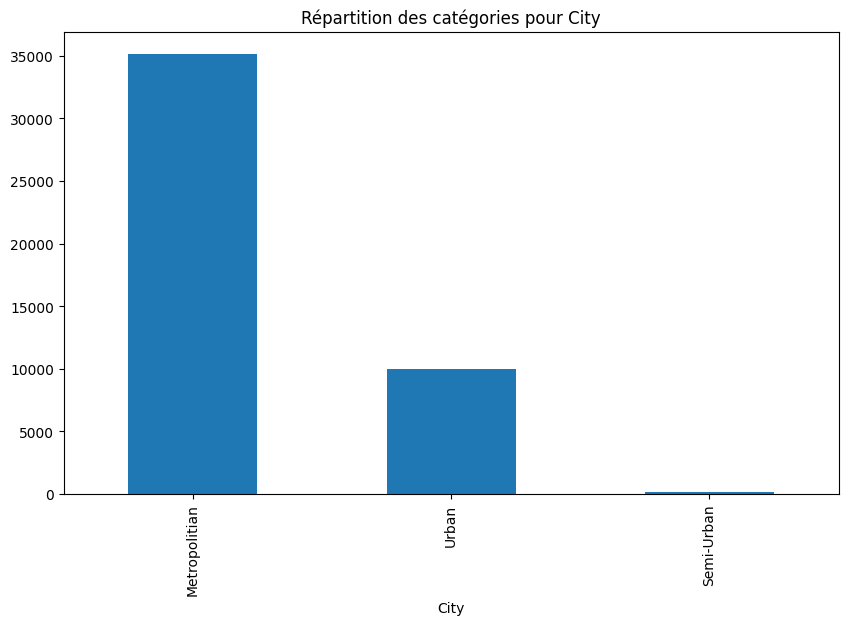

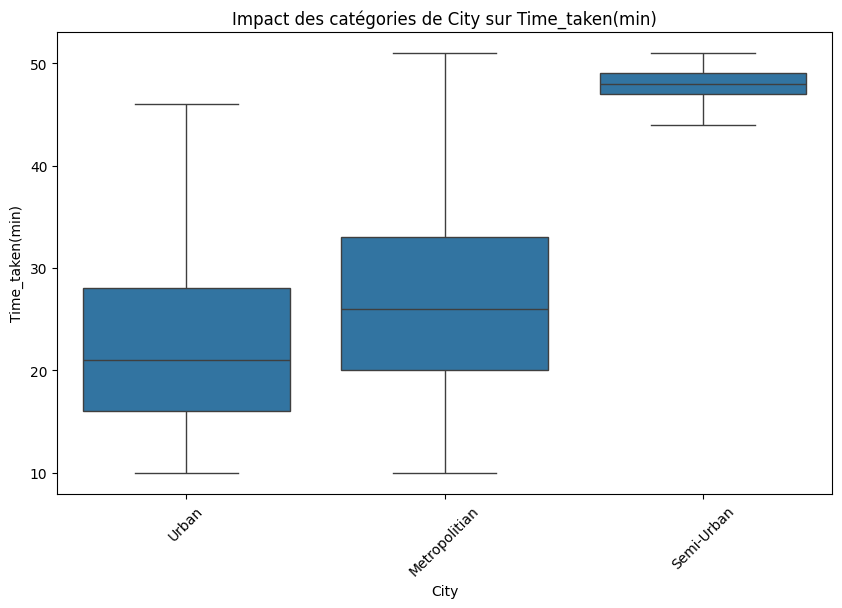

In [16]:
# enlever la baisement de semi-urban
df_set['City'] = df_set['City'].str.strip()

# Capter les valeurs abérentes
categories = df_set['City'].unique()
outliers = {}

for category in categories:
    subset = df_set[df_set['City'] == category]['Time_taken(min)']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[category] = subset[(subset < lower_bound) | (subset > upper_bound)]

print (outliers)

# imputer les valeurs abérentes par "Metropolitian"
for category, values in outliers.items():
    # Remplacer les valeurs de Road_traffic_density par NaN pour les lignes correspondantes
    df_set.loc[
        (df_set['City'] == category) & (df_set['Time_taken(min)'].isin(values)),
        'City'
    ] = np.nan
# imputer les valeur null
df_set.update(df_set['City'].fillna(df_set['City'].mode()[0]))


draw_categ(df_set, 'City')
draw_categ_impact(df_set, "City", "Time_taken(min)")

- Myltipe_deliveries
  

In [17]:
print(df_set.multiple_deliveries.unique())
print(df_set.isnull().sum())
print(len(df_set))

['0' '1' '3' nan '2']
Delivery_person_Age            1784
Delivery_person_Ratings        1838
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1648
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_vehicle                   0
multiple_deliveries             989
City                              0
Time_taken(min)                   0
dtype: int64
45255


In [18]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

# Identifier les valeurs valides et aberrantes
valid_values = ['0', '1']
invalid_indices = ~df_set['multiple_deliveries'].isin(valid_values)  # Indices des valeurs invalides

# Convertir les valeurs invalides en NaN
df_set.loc[invalid_indices, 'multiple_deliveries'] = np.nan

# Sélectionner les colonnes nécessaires pour l'analyse
columns_to_encode = ['Vehicle_condition', 'Type_of_vehicle', 'City', 'Weatherconditions']
columns_to_keep = columns_to_encode + ['Time_taken(min)', 'multiple_deliveries']

# Créez une copie du DataFrame avec uniquement les colonnes nécessaires
df_selected = df_set[columns_to_keep]

# Encoder les colonnes catégoriques sélectionnées
df_encoded = pd.get_dummies(df_selected, columns=columns_to_encode, drop_first=True)

# Séparer les données complètes et les données avec valeurs à imputer
complete_rows = df_encoded[df_encoded['multiple_deliveries'].notnull()]
missing_rows = df_encoded[df_encoded['multiple_deliveries'].isnull()]

# Préparer X (features) et y (target)
X_complete = complete_rows.drop(columns=['multiple_deliveries'])
y_complete = complete_rows['multiple_deliveries'].astype(int)  # Convertir en int pour kNN

# Modèle kNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_complete, y_complete)

# Prédire les valeurs manquantes (NaN ou valeurs aberrantes)
X_missing = missing_rows.drop(columns=['multiple_deliveries'])
predictions = knn.predict(X_missing)

# Mettre à jour les valeurs prédites dans le DataFrame original
df_set.loc[df_set['multiple_deliveries'].isnull(), 'multiple_deliveries'] = predictions.astype(str)

# Convertir toute la colonne en chaînes de caractères pour garantir la cohérence
df_set['multiple_deliveries'] = df_set['multiple_deliveries'].astype(str)

# Afficher les valeurs uniques après traitement
print(df_set['multiple_deliveries'].unique())



['0' '1']


In [19]:
print(df_set.isnull().sum())

Delivery_person_Age            1784
Delivery_person_Ratings        1838
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1648
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_vehicle                   0
multiple_deliveries               0
City                              0
Time_taken(min)                   0
dtype: int64


- Vehicle_condition

In [20]:
df_set = df_set.drop(columns=['Vehicle_condition'])

<br>

- ### <span style="color:blue">Variables numériques</span> <br>
- Delivery_person_Age

In [21]:
# Change type
df_set['Delivery_person_Age']=df_set['Delivery_person_Age'].astype(float)

# Imputer les valeurs null
df_set['Delivery_person_Age']= df_set['Delivery_person_Age'].fillna(df_set.Delivery_person_Age.median())

# Eliminer les valeurs illogique
df_set = df_set.loc[(df_set['Delivery_person_Age'] >= 18) & (df_set['Delivery_person_Age'] <= 45)]

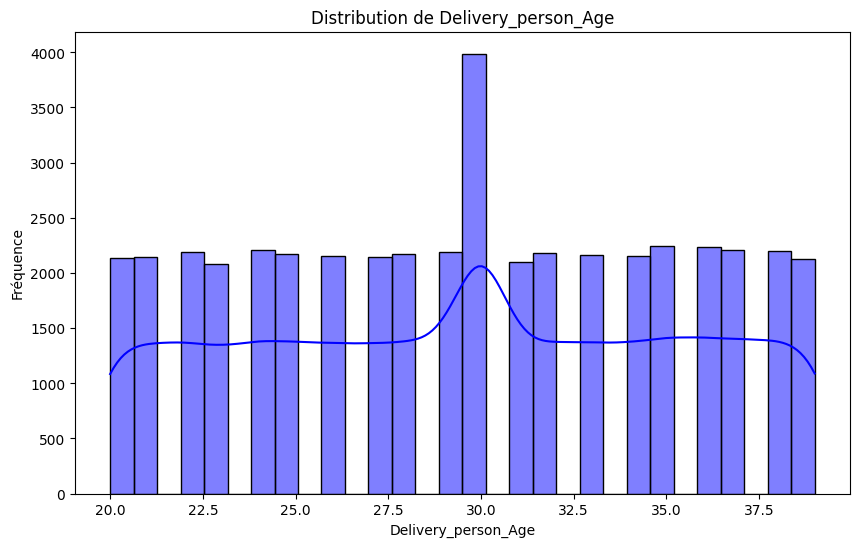

In [22]:
draw_variable(df_set, 'Delivery_person_Age')

- Delivery_person_Ratings

In [23]:
# Change type
df_set['Delivery_person_Ratings']=df_set['Delivery_person_Ratings'].astype(float)

In [24]:
df_set['Delivery_person_Ratings']=df_set['Delivery_person_Ratings'].fillna(df_set.Delivery_person_Ratings.median())

In [25]:
print(df_set.isnull().sum())

Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1572
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Type_of_vehicle                   0
multiple_deliveries               0
City                              0
Time_taken(min)                   0
dtype: int64


<br>

- ### <span style="color:blue">Variables temporelles</span> <br>
- Order_Date

In [26]:
# Conversion des colonnes temporelles
df_set['Order_Date'] = pd.to_datetime(df_set['Order_Date'], format='%d-%m-%Y', errors='coerce')

- Time_Orderd

In [27]:
# Supprimer les données illogiques quand le temps de commande et superieur au celui de prise de commade
# Ajouter une date fictive pour effectuer la conversion
df_set['Time_Orderd'] = pd.to_datetime('2023-01-01 ' + df_set['Time_Orderd'], errors='coerce')
df_set['Time_Order_picked'] = pd.to_datetime('2023-01-01 ' + df_set['Time_Order_picked'], errors='coerce')

# Conversion explicite des colonnes avec un format spécifié
df_set['Time_Orderd'] = pd.to_datetime(df_set['Time_Orderd'], errors='coerce')
df_set['Time_Order_picked'] = pd.to_datetime(df_set['Time_Order_picked'], errors='coerce')

In [28]:
#Imputer les valeurs manquantes de time_orderd
df_set.update(df_set['Time_Orderd'].fillna(df_set['Time_Orderd'].median()))

# Suppression des lignes où `Time_Order_Picked` est avant `Time_Order`
df_set = df_set[df_set['Time_Order_picked'] >= df_set['Time_Orderd']]

# Supprimer Time_Orderd car il n'est plus utile
df_set = df_set.drop(columns=['Time_Orderd'])

In [29]:
df_set.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
City                           0
Time_taken(min)                0
dtype: int64

- Time_Order_picked

In [30]:
# Creating two new column for hours
df_set['Hour_order_picked']=df_set['Time_Order_picked'].dt.hour

<br>

## Features Engineering
<br>

<br>

- ### <span style="color:blue">Variables temporelles</span> <br>
- isWeekend

In [31]:
# Extraire les jours des livraisons
df_set['Order_Weekday'] = df_set['Order_Date'].dt.day_name()

# Ajouter la nouvelle valeur pour savoir si la livraison a été faite au weekend
df_set['Is_Weekend'] = df_set['Order_Weekday'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Supprimer les variables unitiles
df_set = df_set.drop(columns=['Order_Date', 'Order_Weekday'])

- delivery_time

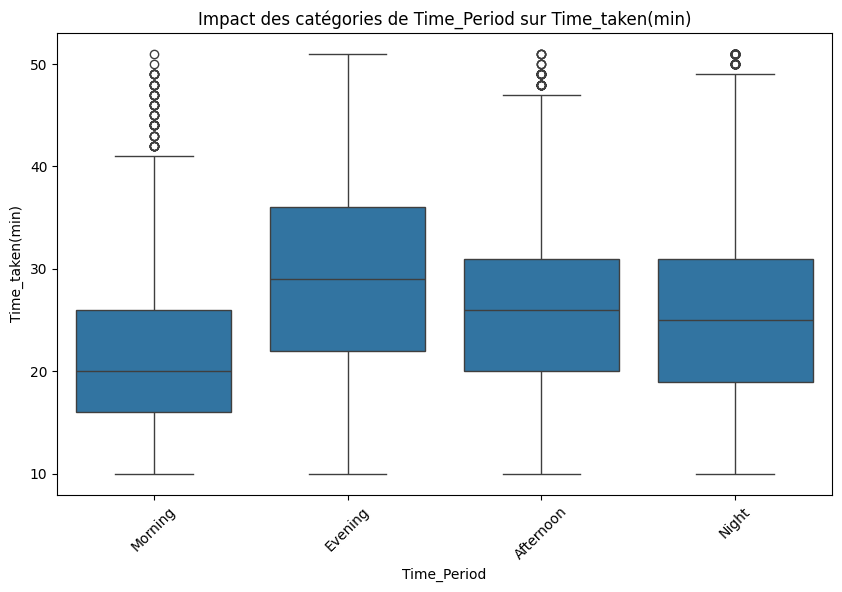

In [32]:
# Ajouter la nouvelle variable pour la plage horaire de livraison
df_set['Time_Period'] = df_set['Hour_order_picked'].apply(get_time_period)
draw_categ_impact(df_set, 'Time_Period', 'Time_taken(min)')

<br>

- ### <span style="color:blue">Variables numériques</span> <br>
- distance_kmetre

In [33]:

# Define a function to calculate distance
'''
def calculate_distance(row):
    restaurant_coords = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery_coords = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant_coords, delivery_coords).kilometers
    '''
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Rayon de la Terre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# Apply the function to the DataFrame
df_set['distance_km'] = haversine(
    df_set['Restaurant_latitude'],
    df_set['Restaurant_longitude'],
    df_set['Delivery_location_latitude'],
    df_set['Delivery_location_longitude']
)
# df_set['distance_km'] = df_set.apply(calculate_distance, axis=1)


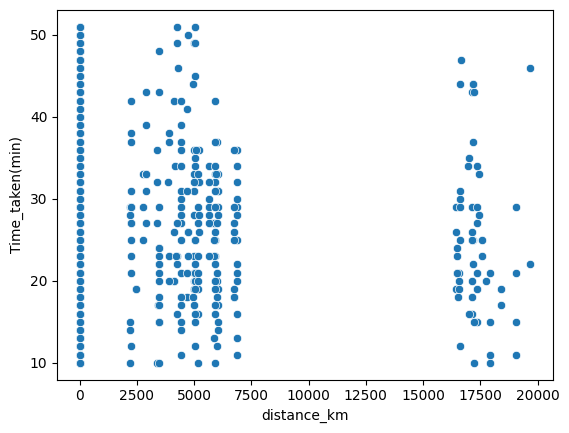

In [34]:
sns.scatterplot(data=df_set, x='distance_km', y='Time_taken(min)')
plt.show()

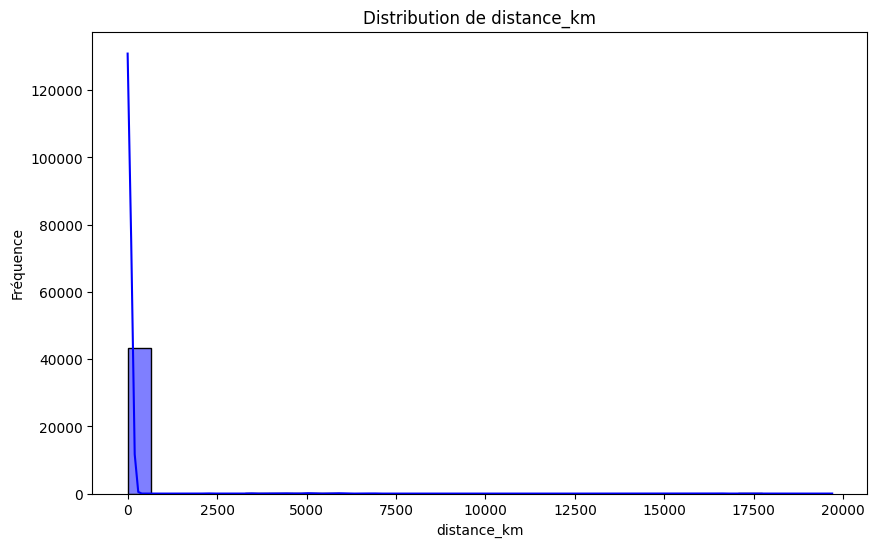

In [35]:
draw_variable(df_set, 'distance_km')

In [36]:
df_set

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,multiple_deliveries,City,Time_taken(min),Hour_order_picked,Is_Weekend,Time_Period,distance_km
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2023-01-01 11:45:00,Sunny,High,motorcycle,0,Urban,24.0,11,1,Morning,3.025149
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2023-01-01 19:50:00,Stormy,Jam,scooter,1,Metropolitian,33.0,19,0,Evening,20.183530
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2023-01-01 08:45:00,Sandstorms,Low,motorcycle,1,Urban,26.0,8,1,Morning,1.552758
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2023-01-01 18:10:00,Sunny,Medium,motorcycle,1,Metropolitian,21.0,18,0,Evening,7.790401
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2023-01-01 13:45:00,Cloudy,High,scooter,1,Metropolitian,30.0,13,1,Afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2023-01-01 21:55:00,Windy,Jam,motorcycle,1,Metropolitian,33.0,21,0,Night,16.600272
45588,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2023-01-01 11:45:00,Windy,High,motorcycle,0,Metropolitian,32.0,11,0,Morning,1.489846
45589,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2023-01-01 20:10:00,Windy,Jam,motorcycle,1,Metropolitian,36.0,20,0,Evening,11.007735
45591,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2023-01-01 13:40:00,Cloudy,High,motorcycle,1,Metropolitian,26.0,13,0,Afternoon,6.232393


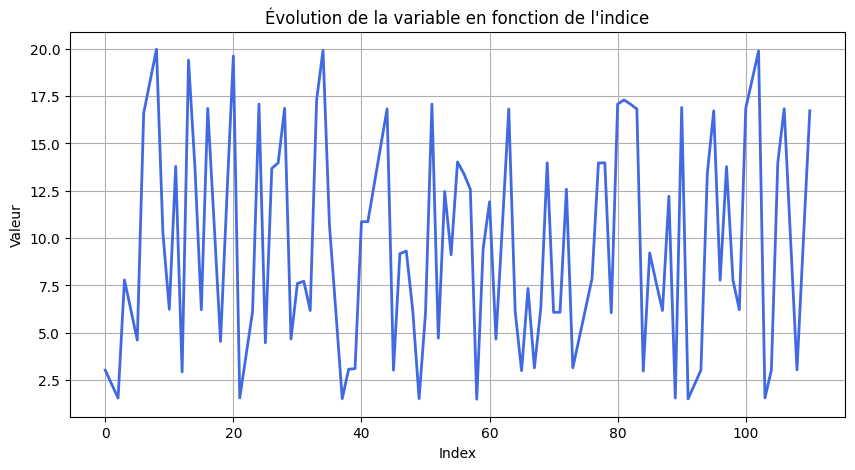

In [37]:
# eliminer les distances illogiques
df_set = df_set[(df_set['distance_km'] > 0) & (df_set['distance_km'] < 20)]


plt.figure(figsize=(10, 5))
plt.plot(df_set['distance_km'].iloc[:100], color='royalblue', linewidth=2)
plt.title("Évolution de la variable en fonction de l'indice")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.grid(True)
plt.show()

<br>

- ### <span style="color:blue">Variables restantes</span> <br>
- Road_traffic_density

In [38]:
# imputer les variables null
probs = df_set['Road_traffic_density'].value_counts(normalize=True)
df_set['Road_traffic_density'] = df_set['Road_traffic_density'].apply(lambda x: np.random.choice(probs.index, p=probs.values) if pd.isnull(x) else x)

df_set.isnull().sum()

C:\Users\issaa\AppData\Local\Temp\ipykernel_24800\2807755056.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_set['Road_traffic_density'] = df_set['Road_traffic_density'].apply(lambda x: np.random.choice(probs.index, p=probs.values) if pd.isnull(x) else x)


Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
City                           0
Time_taken(min)                0
Hour_order_picked              0
Is_Weekend                     0
Time_Period                    0
distance_km                    0
dtype: int64

In [39]:
print(df_set)

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
0                     37.0                      4.9            22.745049   
2                     23.0                      4.4            12.914264   
3                     38.0                      4.7            11.003669   
4                     32.0                      4.6            12.972793   
5                     22.0                      4.8            17.431668   
...                    ...                      ...                  ...   
45587                 35.0                      4.2            23.371292   
45588                 30.0                      4.8            26.902328   
45589                 21.0                      4.6             0.000000   
45591                 20.0                      4.7            11.001753   
45592                 23.0                      4.9            23.351058   

       Restaurant_longitude  Delivery_location_latitude  \
0                 75.892471 

<br>

## Encoder les variables categorielles
<br>

In [40]:
df_set.select_dtypes(include='object').columns
columns = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle',
       'multiple_deliveries', 'City', 'Time_Period']
df_set[columns]

,Weatherconditions,Road_traffic_density,Type_of_vehicle,multiple_deliveries,City,Time_Period
0,Sunny,High,motorcycle,0,Urban,Morning
2,Sandstorms,Low,motorcycle,1,Urban,Morning
3,Sunny,Medium,motorcycle,1,Metropolitian,Evening
4,Cloudy,High,scooter,1,Metropolitian,Afternoon
5,Cloudy,Jam,motorcycle,1,Urban,Night
...,...,...,...,...,...,...
45587,Windy,Jam,motorcycle,1,Metropolitian,Night
45588,Windy,High,motorcycle,0,Metropolitian,Morning
45589,Windy,Jam,motorcycle,1,Metropolitian,Evening
45591,Cloudy,High,motorcycle,1,Metropolitian,Afternoon


In [41]:
df_encoded = df_set.copy()

label_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'City', 'Time_Period']

# Appliquer LabelEncoder sur ces colonnes
le = LabelEncoder()

for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


# Appliquer OneHotEncoder sur 'multiple_deliveries'
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' pour éviter la multicolinéarité

ohe_encoded = ohe.fit_transform(df_encoded[['multiple_deliveries']])

ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(['multiple_deliveries']))

# Combiner les deux jeux
df_encoded = pd.concat([df_encoded.drop(columns=['multiple_deliveries']).reset_index(drop=True),
                        ohe_df.reset_index(drop=True)], axis=1)



In [58]:

label_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'City', 'Time_Period']

label_mappings = {}

for col in label_cols:
    le = LabelEncoder()
    le.fit(df_set[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    label_mappings[col] = mapping

# Afficher les mappings
for col, mapping in label_mappings.items():
    print(f"Mapping pour {col}:")
    for original, code in mapping.items():
        print(f"  {original} --> {code}")
    print("-" * 30)


Mapping pour Weatherconditions:
  Cloudy --> 0
  Fog --> 1
  Sandstorms --> 2
  Stormy --> 3
  Sunny --> 4
  Windy --> 5
------------------------------
Mapping pour Road_traffic_density:
  High  --> 0
  Jam  --> 1
  Low  --> 2
  Medium  --> 3
------------------------------
Mapping pour Type_of_vehicle:
  electric_scooter --> 0
  motorcycle --> 1
  scooter --> 2
------------------------------
Mapping pour City:
  Metropolitian --> 0
  Semi-Urban --> 1
  Urban --> 2
------------------------------
Mapping pour Time_Period:
  Afternoon --> 0
  Evening --> 1
  Morning --> 2
  Night --> 3
------------------------------


<br>

## Calculer la correlation
<br>

In [42]:
df_encoded.dtypes

Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Time_Order_picked              datetime64[ns]
Weatherconditions                       int64
Road_traffic_density                    int64
Type_of_vehicle                         int64
City                                    int64
Time_taken(min)                       float64
Hour_order_picked                       int32
Is_Weekend                              int64
Time_Period                             int64
distance_km                           float64
multiple_deliveries_1                 float64
dtype: object

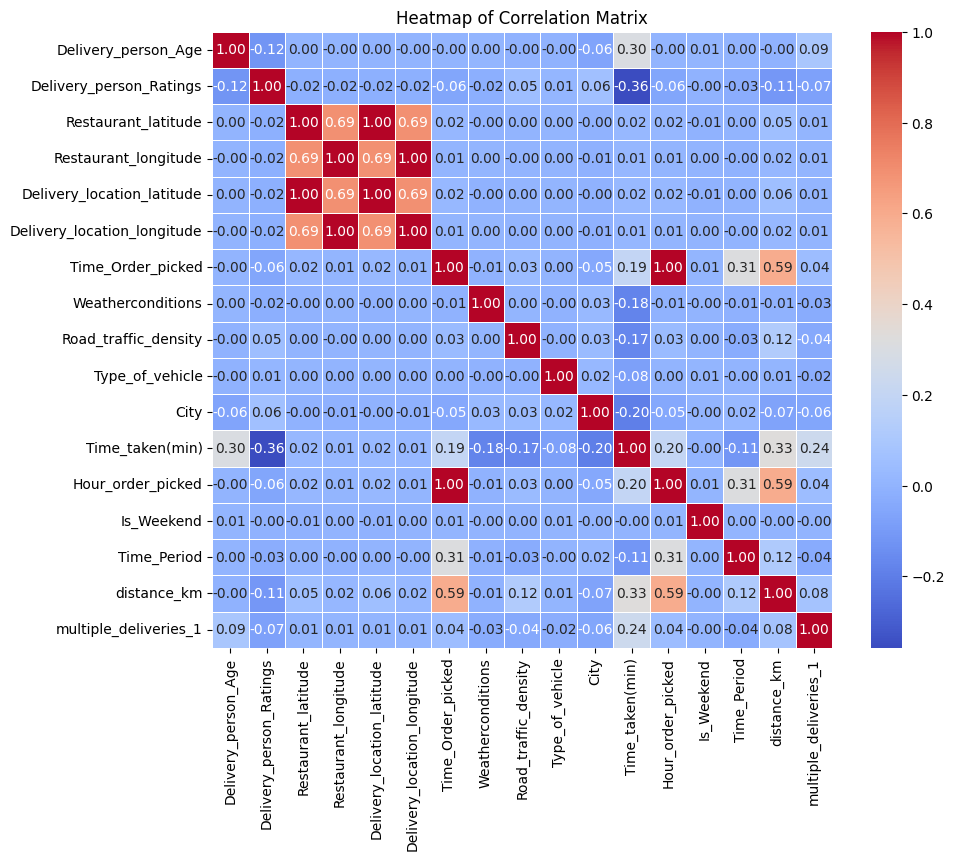

In [43]:
# Calculer la matrice de corrélation
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

<br>

## Preparer le modèle
<br>

In [44]:
df_model = df_encoded.copy()
df_model.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
City                           0
Time_taken(min)                0
Hour_order_picked              0
Is_Weekend                     0
Time_Period                    0
distance_km                    0
multiple_deliveries_1          0
dtype: int64

In [45]:
print(df_model)

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
0                     37.0                      4.9            22.745049   
1                     23.0                      4.4            12.914264   
2                     38.0                      4.7            11.003669   
3                     32.0                      4.6            12.972793   
4                     22.0                      4.8            17.431668   
...                    ...                      ...                  ...   
41252                 35.0                      4.2            23.371292   
41253                 30.0                      4.8            26.902328   
41254                 21.0                      4.6             0.000000   
41255                 20.0                      4.7            11.001753   
41256                 23.0                      4.9            23.351058   

       Restaurant_longitude  Delivery_location_latitude  \
0                 75.892471 

In [46]:
# renommer le nom de variable cible
df_model = df_model.rename(columns={'Time_taken(min)':'Time_taken'})

# Preparer x, y
x= df_model.drop(['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Time_Order_picked', 'Is_Weekend', 'Time_taken'],axis=1)
y= df_model.Time_taken

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [60]:
print(x_train)

       Delivery_person_Age  Delivery_person_Ratings  Weatherconditions  \
30417                 23.0                      4.9                  2   
40062                 23.0                      4.8                  2   
25126                 32.0                      4.6                  4   
13997                 30.0                      5.0                  0   
9064                  23.0                      4.0                  2   
...                    ...                      ...                ...   
6265                  38.0                      4.8                  0   
11284                 28.0                      4.7                  3   
38158                 24.0                      4.9                  3   
860                   24.0                      4.7                  5   
15795                 22.0                      4.7                  1   

       Road_traffic_density  Type_of_vehicle  City  Hour_order_picked  \
30417                     1           

<br>

## Normaliser la data set
<br>

In [49]:
#sc = StandardScaler()

In [50]:
#sc.fit(x_train)

In [51]:
#x_train = sc.fit_transform(x_train)
#x_test = sc.transform(x_test)

<br>

## Appliquer le modèle Random Forest Regressor
<br>

In [52]:
rfr = RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [53]:
rfr.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [54]:
rfr_pred = rfr.predict(x_test)

In [55]:
print(r2_score(y_test,rfr_pred))

0.7592698507678116


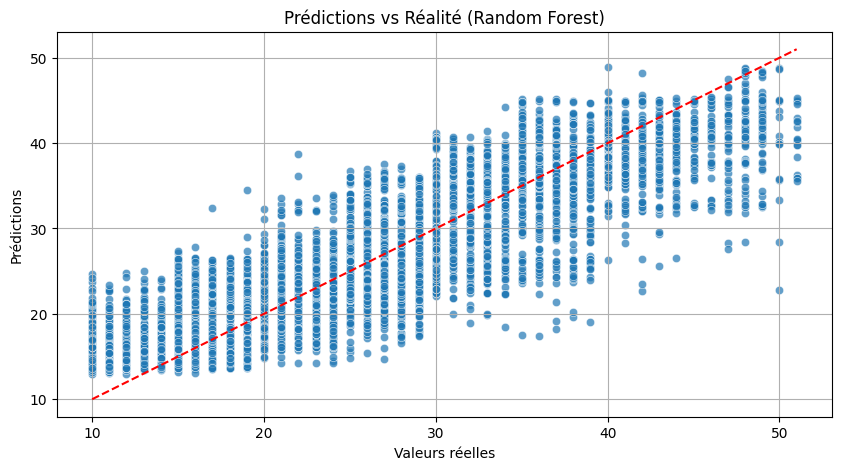

In [56]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=rfr_pred, alpha=0.7)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réalité (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid()
plt.show()

In [57]:
with open('modele.pkl', 'wb') as f:
    pickle.dump(rfr, f)

In [61]:
new_data = pd.DataFrame({
    'Delivery_person_Age': [23],
    'Delivery_person_Ratings': [4.9],
    'Weatherconditions': [5],
    'Road_traffic_density': [1],
    'Type_of_vehicle': [2],
    'City': [0],
    'Hour_order_picked': [19],
    'Time_Period': [1],
    'distance_km': [13.5],
    'multiple_deliveries_1': [0.0]
})

predictions = rfr.predict(new_data)

print("Prédictions :", predictions)

Prédictions : [22.19084467]
